In [25]:
import numpy as np
import matplotlib.pyplot as plt
import verde as vd
import harmonica as hm
import boule as bl
import choclo
from numpy.linalg import inv
import spherical as sph

In [26]:
TESLA_TO_NANOTESLA = 1e9

ellipsoid = bl.WGS84

coordinates = vd.grid_coordinates(
    region=(-5, 5, -5, 5),
   shape=(40,40),
    extra_coords=ellipsoid.mean_radius,
)

# coordinates = vd.scatter_points(
#     region=(-3, 4, -2, 3),
#    size = 100,
#     extra_coords=ellipsoid.mean_radius,
# )


longitude, sph_latitude, radius_obs = tuple(c.ravel() for c in coordinates)

magnetic_moments = (
    np.full((1, 1), 0.0e9),  
    np.full((1, 1), 0.0e9),        
    np.full((1, 1), 1.0e13)       
)

dipoles = vd.scatter_points(
    region=(-1, 1,-1, 1),
    size= 1,
    extra_coords=ellipsoid.mean_radius - 5e4,
    random_state=0
)

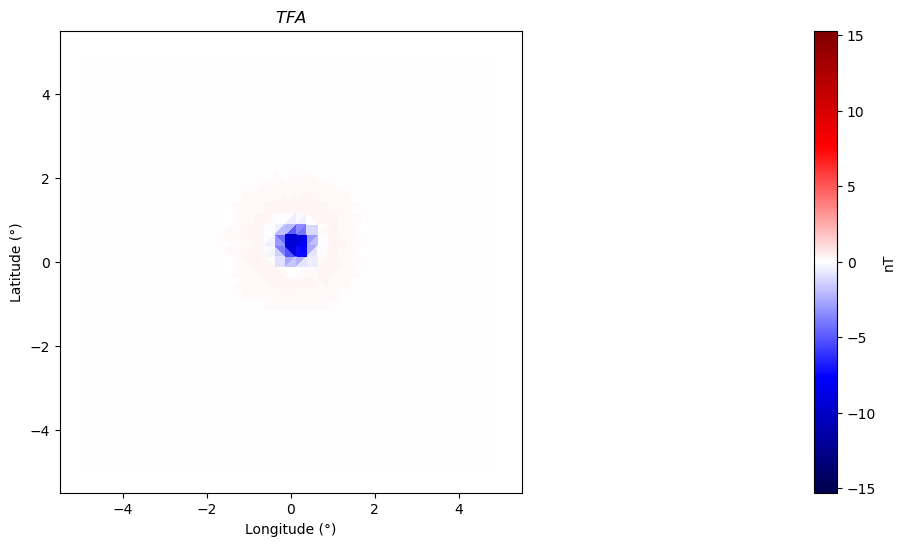

In [27]:
b_long, b_colat, b_radius = sph.foward_modeling_spherical(coordinates, dipoles, magnetic_moments)

observed_data = hm.total_field_anomaly((b_long, b_colat, b_radius), inclination=90, declination=0)

scale = vd.maxabs(observed_data)

plt.figure(figsize=(15, 6))
plt.tripcolor(longitude, sph_latitude, observed_data, cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.title('$TFA$')
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.axis("scaled")

plt.show()


In [28]:
def jacobian(coordinates, dipoles, inclination, declination, I_F, D_F):

    coordinates = tuple(c.ravel() for c in coordinates)
    dipoles = tuple(d.ravel() for d in dipoles)
    
    m = dipoles[0].size
    n = coordinates[0].size
    A = np.empty((n, m))

    magnetic_moments = hm.magnetic_angles_to_vec(np.array([1]), np.array([inclination]), np.array([declination]))

    for j in range(m):
         
        b_latitude, b_colatitude, b_radius = sph.foward_modeling_spherical(coordinates, (dipoles[0][j],dipoles[1][j],dipoles[2][j]), magnetic_moments)
        A[:, j] = hm.total_field_anomaly((b_latitude, b_colatitude, b_radius),I_F, D_F)

    return A

In [29]:
estimated_source_coord =  tuple(c.ravel() for c in vd.grid_coordinates(
    region=(-5, 5, -5, 5),
    shape=(40, 40),
    extra_coords=ellipsoid.mean_radius - 5e5
))

A = jacobian(
    coordinates,
    estimated_source_coord,
    90,
    0,
    I_F=90,
    D_F=0)

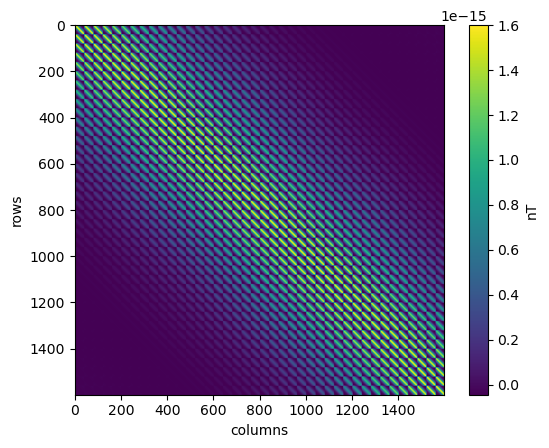

In [30]:
plt.figure()
plt.imshow(A)
plt.colorbar(label="nT")
plt.xlabel("columns")
plt.ylabel("rows")
plt.show()


In [31]:
def calculate_coefficients(observed_data, A, damping):
    
    I = np.identity(A.shape[1]) # needs to = m x m
    # np.shape(A) = A.shape
    
    # The @ operator can be used for conventional matrix multiplication.
    system_matrix = A.T @ A + I * damping
    system_rhs_vector = A.T @ observed_data
    
    coefficients = np.linalg.solve(system_matrix, system_rhs_vector)
    
    return coefficients

In [32]:
damping = 1e-7

coefficients = calculate_coefficients(observed_data, A, damping)

# print(coefficients)

In [33]:
#Não faz sentido
grid_coord = vd.grid_coordinates(region= (-5, 5, -5, 5), shape=(100,100), extra_coords=ellipsoid.mean_radius + 100)
grid_0, grid_1, grid_2 = tuple(g.ravel() for g in grid_coord)

grid_data = np.zeros(np.shape(grid_coord[0]))


m = estimated_source_coord[0].size

magnetic_moments = hm.magnetic_angles_to_vec(np.array([1]), np.array([90]), np.array([1]))


for j in range(m):

    b_latitude, b_colatitude, b_radius = sph.foward_modeling_spherical(grid_coord, (estimated_source_coord[0][j],estimated_source_coord[1][j],estimated_source_coord[2][j]), magnetic_moments)
    grid_data =+ coefficients[j] * hm.total_field_anomaly((b_latitude, b_colatitude, b_radius),90, 0)

In [34]:
b_long_obs, b_colat_obs, b_radius_obs = sph.foward_modeling_spherical(grid_coord, dipoles, magnetic_moments)
grid_obs = hm.total_field_anomaly((b_long_obs, b_colat_obs, b_radius_obs), 90,0)

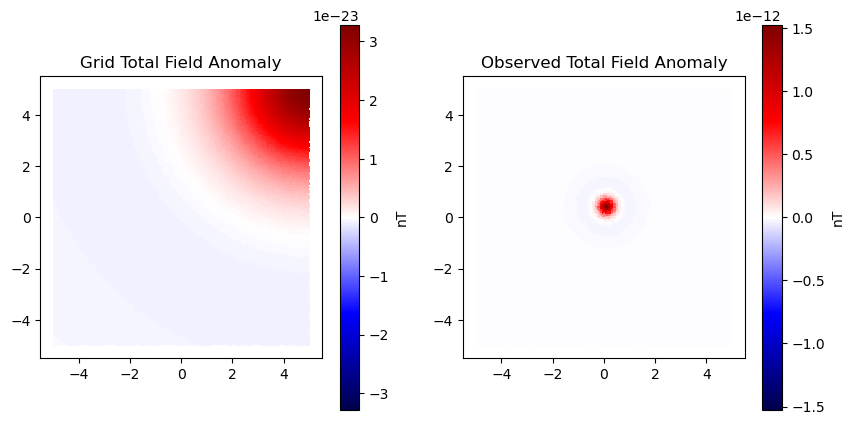

In [35]:
plt.figure(figsize=(10, 5))
scale = vd.maxabs(grid_data)
plt.subplot(1, 2, 1)
plt.tripcolor(grid_0, grid_1, grid_data, cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.title('Grid Total Field Anomaly')
plt.axis("scaled")

plt.subplot(1,2,2)
scale_obs = vd.maxabs(grid_obs)
plt.tripcolor(grid_0, grid_1, grid_obs, cmap="seismic", vmin=-scale_obs, vmax=scale_obs)
plt.colorbar(label='nT')
plt.title('Observed Total Field Anomaly')
plt.axis("scaled")

plt.show()

Text(0.5, 1.0, 'Difference')

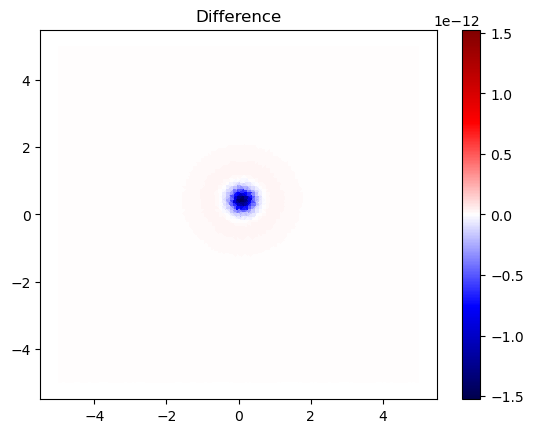

In [36]:
diff = grid_data - grid_obs
scale = vd.maxabs(diff)
plt.tripcolor(grid_0, grid_1, diff,cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar()
plt.title('Difference')

In [37]:
mse = np.square(diff).mean() 
rmse = np.sqrt(mse)
rmse

np.float64(5.4519107660854586e-14)

## Oi Arthur do futuro

Onde paramos? 

Você descobriu em uma conversa com o Leo que cagou no pau ao calcular a jacobiana, seu merda

Então temos que pensar em como concertar isso, pelo o que o leo dise era pra ficar mais ou menos assim: https://github.com/compgeolab/2020-aachen-inverse-problems/blob/main/gravity-inversion-solution.ipynb

no momento não sei o que fazer, mas tentei iterar em cima dos dipolos e dos momentos e nd deu certo até então, olha o código 05-eql da india